# Exercise 2.1
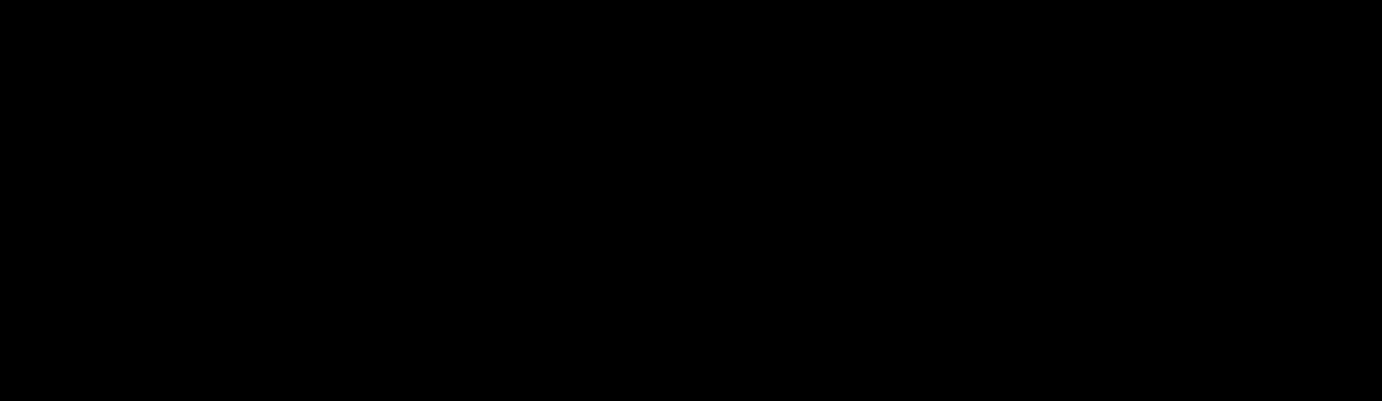
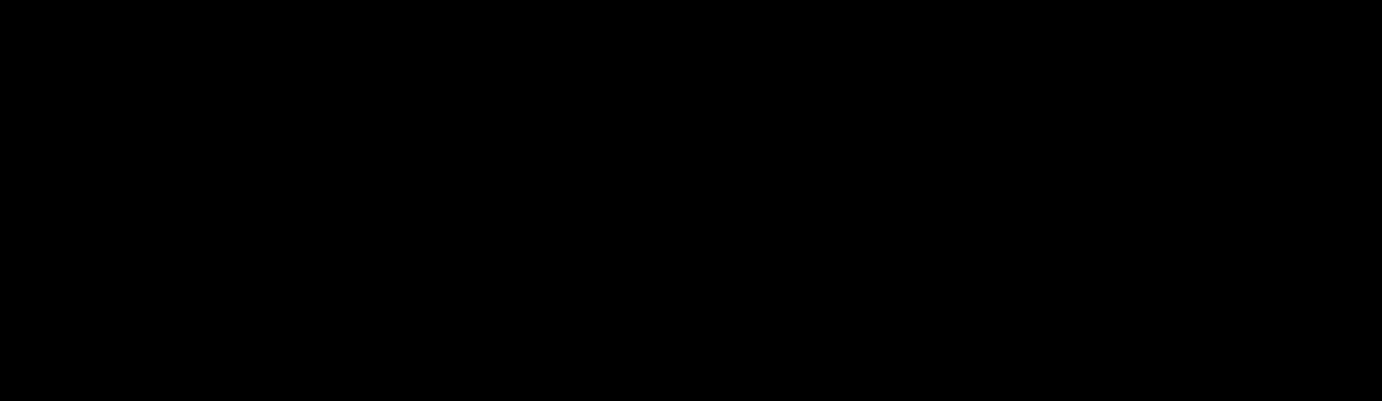
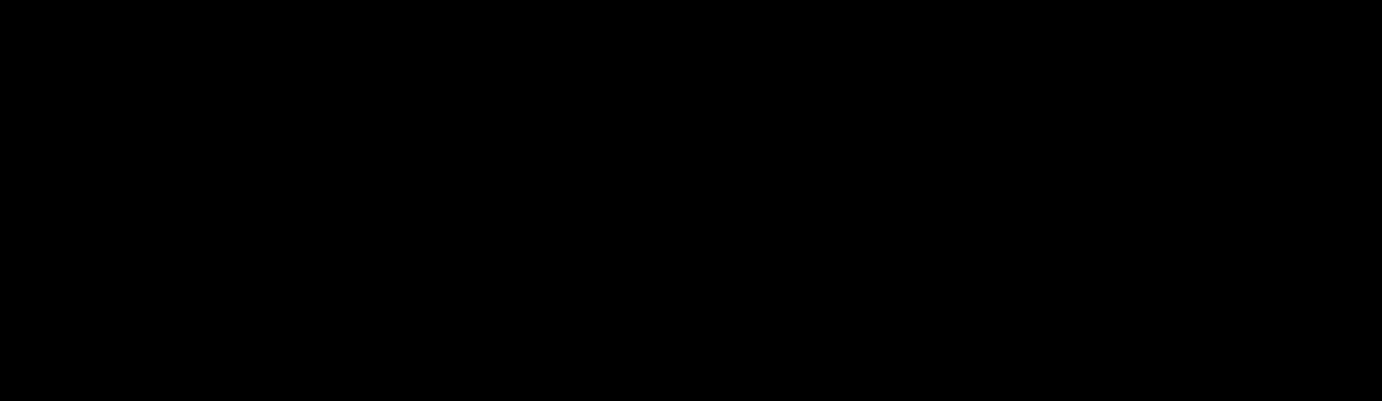

Objectives:
1.	Figure out the most memory-efficient way to store a lot of data.
2.	Learn about different ways of representing records including tuples, dictionaries, classes, and named tuples.
In this exercise, we look at different choices for representing data structures with an eye towards memory use and efficiency. A lot of people use Python to perform various kinds of data analysis so knowing about different options and their tradeoffs is useful information.

## (a) Stuck on the bus

The file Data/ctabus.csv is a CSV file containing daily ridership data for the Chicago Transit Authority (CTA) bus system from January 1, 2001 to August 31, 2013. It contains approximately 577000 rows of data. Use Python to view a few lines of data to see what it looks like:


In [ ]:
from _csv import Reader

f = open('Data/ctabus.csv')

In [ ]:
next(f)

In [ ]:
next(f)

In [ ]:
next(f)

There are 4 columns of data.
1.	route: Column 0. The bus route name.
2.	date: Column 1. A date string of the form MM/DD/YYYY.
3.	daytype: Column 2. A day type code (U=Sunday/Holiday, A=Saturday, W=Weekday)
4.	rides: Column 3. Total number of riders (integer)

The rides column records the total number of people who boarded a bus on that route on a given day. Thus, from the example, 7354 people rode the number 3 bus on January 1, 2001.


## (b) Basic memory use of text
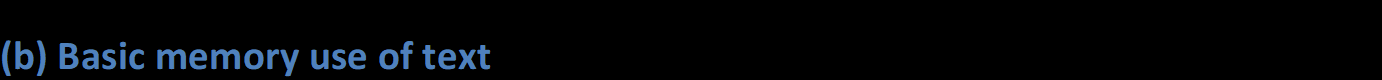

In [ ]:
import tracemalloc
f = open('Data/ctabus.csv')

In [ ]:
tracemalloc.start()

In [ ]:
data = f.read()
len(data)

In [ ]:
current, peak = tracemalloc.get_traced_memory()

In [ ]:
current

In [ ]:
peak

Your results might vary somewhat, but you should see current memory use in the range of 12MB with a peak of 24MB.
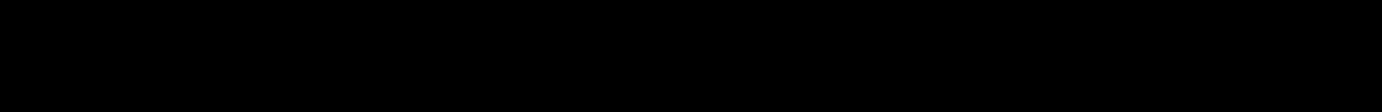

What happens if you read the entire file into a list of strings instead? Restart Python and try this:

In [ ]:
import tracemalloc
f = open('Data/ctabus.csv')
tracemalloc.start()
lines = f.readlines()
len(lines)

In [ ]:
current, peak = tracemalloc.get_traced_memory()

In [ ]:
current

In [ ]:
peak

You should see the memory use go up significantly into the range of 40-50MB. Point to ponder: what might be the source of that extra overhead?

## (c) A List of Tuples

In practice, you might read the data into a list and convert each line into some other data structure. Here is a program readrides.py that reads the entire file into a list of tuples using the csv module:

readrides.py

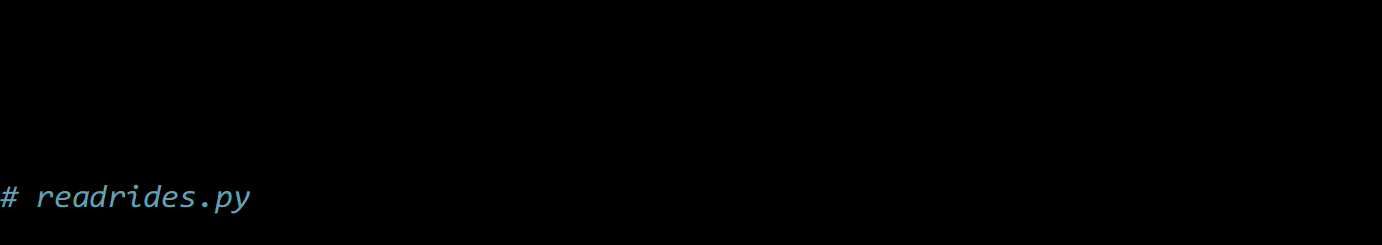

In [ ]:
%%writefile readrides.py
import csv

def read_rides_as_tuples(filename):
    '''
    Read the bus ride data as a list of tuples
    '''
    records = []
    with open(filename) as f:
        rows = csv.reader(f)
        headings = next(rows)     # Skip headers
        for row in rows:
            route = row[0]
            date = row[1]
            daytype = row[2]
            rides = int(row[3])
            record = (route, date, daytype, rides)
            records.append(record)
    return records

if __name__ == '__main__':
    import tracemalloc
    tracemalloc.start()
    rows = read_rides_as_tuples('Data/ctabus.csv')
    print('Memory Use: Current %d, Peak %d' % tracemalloc.get_traced_memory())


In [ ]:
len(rows)

In [ ]:
rows[0]

In [ ]:
rows[1]

## (d) Memory Use of Other Data Structures
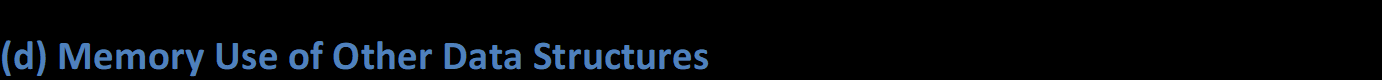

Python has many different choices for representing data structures. For example:
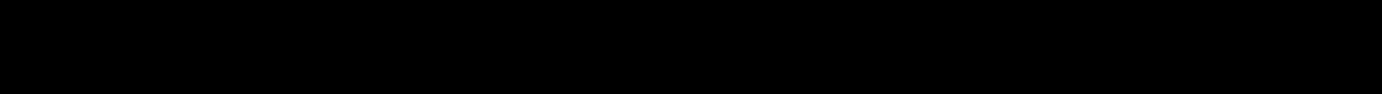

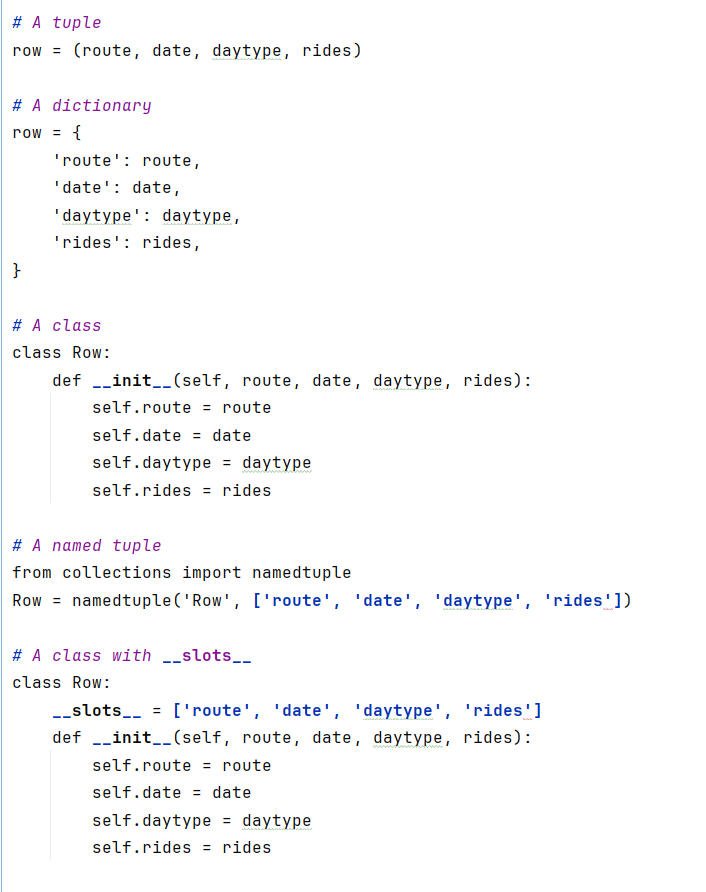

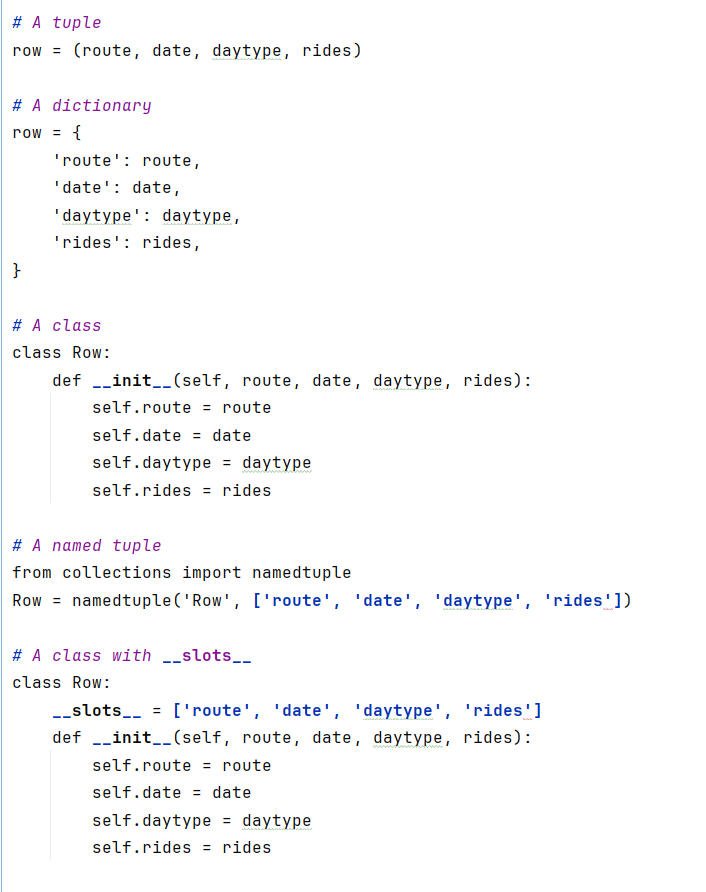

### Your task is as follows:
1. Create different versions of the read_rides() function that use each of these data structures to represent a single row of data.
2. find out the resulting memory use of each option.
3. Find out which approach offers the most efficient storage if you were working with a lot of data all at once.
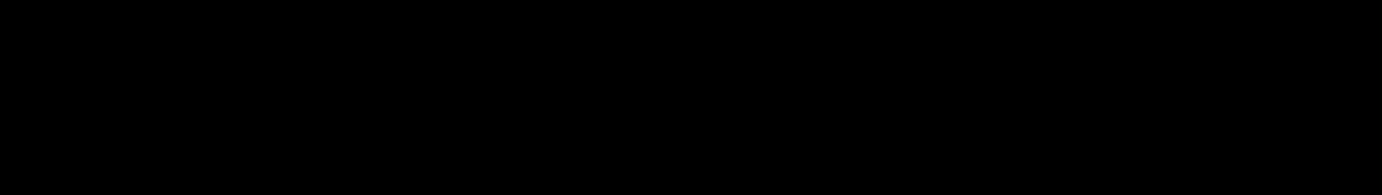

# Exercise 2.2

_Objectives:_

* Work with various containers
* List/Set/Dict Comprehensions
* Collections module
* Data analysis challenge

Most Python programmers are generally familiar with lists, dictionaries, tuples, and other basic datatypes. In this exercise, we'll put that knowledge to work to solve various data analysis problems.

## (a) Preliminaries
To get started, let's review some basics with a slightly simpler dataset--
a portfolio of stock holdings. Create a file readport.py and put this
code in it:

In [ ]:
# %%writefile readport.py

import csv

# A function that reads a file into a list of dicts
def read_portfolio(filename):
    portfolio = []
    with open(filename) as f:
        rows = csv.reader(f)
        headers = next(rows)
        for row in rows:
            record = {
                'name' : row[0],
                'shares' : int(row[1]),
                'price' : float(row[2])
            }
            portfolio.append(record)
    return portfolio

This file reads some simple stock market data in the file Data/portfolio.csv. Use the function to read the file and look at the results:

In [ ]:
portfolio = read_portfolio('Data/portfolio.csv')

In [ ]:
from pprint import pprint
pprint(portfolio)

In this data, each row consists of a stock name, a number of held shares, and a purchase price. There are multiple entries for certain stock names such as MSFT and IBM.

## (b) Comprehensions
List, set, and dictionary comprehensions can be a useful tool for manipulating data. For example, try these operations:

In [ ]:
# Find all holdings more than 100 shares
[s for s in portfolio if s['shares'] > 100]

In [ ]:
# Compute total cost (shares * price)
sum([s['shares']*s['price'] for s in portfolio])

In [ ]:
# Find all unique stock names (set)
{ s['name'] for s in portfolio }

In [ ]:
# Count the total shares of each of stock
totals = { s['name']: 0 for s in portfolio }
for s in portfolio:
        totals[s['name']] += s['shares']

totals

## (c) Collections
The collections module has a variety of classes for more specialized data
manipulation.  For example, the last example could be solved with a Counter like this:

In [ ]:
from collections import Counter
totals = Counter()
for s in portfolio:
        totals[s['name']] += s['shares']

totals

Counters support other kinds of operations such as ranking and mathematics.  For example:

In [ ]:
# Get the two most common holdings
totals.most_common(2)

In [ ]:
# Adding counters together
more = Counter()
more['IBM'] = 75
more['AA'] = 200
more['ACME'] = 30
more

In [ ]:
totals

In [ ]:
totals + more

The defaultdict object can be used to group data.  For example, suppose you want to make it easy to find all matching entries for a given name such as IBM.
Try this:

In [ ]:
from collections import defaultdict
byname = defaultdict(list)
for s in portfolio:
    byname[s['name']].append(s)

In [ ]:
byname['IBM']

In [ ]:
byname['AA']

The key feature that makes this work is that a defaultdict automatically initializes elements for you--allowing an insertion of a new element and an append() operation to be combined together.

## (d) Data Analysis Challenge

In the last exercise you just wrote some code to read CSV-data related to the Chicago Transit Authority.  For example, you can grab the data as dictionaries like this:

In [ ]:
import readrides
rows = readrides.read_rides_as_dicts('Data/ctabus.csv')

It would be a shame to do all of that work and then do nothing with the data. first write the fuction read_rides_as_dicts() in readrides.py that reads the data into a list of dictionaries. Then, write code to answer the following questions:

In this exercise, your task is this: write a program to answer the following questions:

* How many bus routes exist in Chicago?
* How many people rode the number 22 bus on February 2, 2011?  What about any route on any date of your choosing?
* What is the total number of rides taken on each bus route?
* What five bus routes had the greatest ten-year increase in ridership from 2001 to 2011?

You are free to use any technique whatsoever to answer the above
questions as long as it's part of the Python standard library (i.e.,
built-in datatypes, standard library modules, etc.).

# Exercise 2.3

Objectives:

* Iterate like a pro

Files Modified: None.

Iteration is an essential Python skill.  In this exercise, we look at a number of common iteration idioms.

Start the exercise by grabbing some rows of data from a CSV file.

In [ ]:
import csv
f = open('Data/portfolio.csv')
f_csv: Reader = csv.reader(f)
headers = next(f_csv)
headers

In [ ]:
rows = list(f_csv)
from pprint import pprint
pprint(rows)

## (a) Basic Iteration and Unpacking

The for statement iterates over any sequence of data. For example:

In [ ]:
for row in rows:
    print(row)

Unpack the values into separate variables if you need to:

In [ ]:
for name, shares, price in rows:
    print(name, shares, price)

It's somewhat common to use _ or __ as a throw-away variable if you don't care
about one or more of the values.  For example:

In [ ]:
for name, _, price in rows:
    print(name, price)

If you don't know how many values are being unpacked, you can use * as a wildcard.
Try this experiment in grouping the data by name:

In [ ]:
from collections import defaultdict
byname = defaultdict(list)
for name, *data in rows:
        byname[name].append(data)

In [ ]:
byname['IBM']

In [ ]:
byname['CAT']

In [ ]:
for shares, price in byname['IBM']:
    print(shares, price)

## (b) Counting with enumerate()

enumerate() is a useful function if you ever need to keep a counter
or index while iterating. For example, suppose you wanted an extra row
number:

In [ ]:
for rowno, row in enumerate(rows):
    print(rowno, row)

You can combine this with unpacking if you're careful about how you structure it:

In [ ]:
for rowno, (name, shares, price) in enumerate(rows):
    print(rowno, name, shares, price)

## (c) Using the zip() function
The zip() function is most commonly used to pair data.  For example,
recall that you created a headers variable:

In [ ]:
headers

In [ ]:
row = rows[0]
row

In [ ]:
for col, val in zip(headers, row):
    print(col, val)

Or maybe you can use it to make a dictionary:

In [ ]:
dict(zip(headers, row))

Or maybe a sequence of dictionaries:

In [ ]:
for row in rows:
    record = dict(zip(headers, row))
    print(record)

## (d) Generator Expressions
A generator expression is almost exactly the same as a list
comprehension except that it does not create a list.  Instead, it
creates an object that produces the results incrementally--typically
for consumption by iteration. Try a simple example:

In [ ]:
nums = [1,2,3,4,5]
squares = (x*x for x in nums)
squares

In [ ]:
for n in squares:
    print(n)

You will notice that a generator expression can only be used once.
Watch what happens if you do the for-loop again:

In [ ]:
for n in squares:
    print(n)

You can manually get the results one-at-a-time if you use the next() function. Try this:

In [ ]:
squares = (x*x for x in nums)
next(squares)

In [ ]:
next(squares)

In [ ]:
next(squares)

Keeping typing next() to see what happens when there is no
more data.

If the task you are performing is more complicated, you can
still take advantage of generators by writing a generator function
and using the yield statement instead.
For example:

In [ ]:
def squares(nums):
    for x in nums:
        yield x*x

In [ ]:
for n in squares(nums):
    print(n)

We'll return to generator functions a little later in the course--for now,
just view such functions as having the interesting property of feeding
values to the for-statement.

## (e) Generator Expressions and Reduction Functions

Generator expressions are especially useful for feeding data into functions such as sum(), min(), max(),
any(), etc.   Try some examples using the portfolio data from earlier.  Carefully observe that these examples are missing some extra square brackets ([]) that appeared when using list comprehensions.

In [ ]:
from readport import read_portfolio
portfolio = read_portfolio('Data/portfolio.csv')

In [ ]:
sum(s['shares']*s['price'] for s in portfolio)

In [ ]:
min(s['shares'] for s in portfolio)

In [ ]:
any(s['name'] == 'IBM' for s in portfolio)

In [ ]:
all(s['name'] == 'IBM' for s in portfolio)

In [ ]:
sum(s['shares'] for s in portfolio if s['name'] == 'IBM')

The syntax in the above examples takes some getting used to, but the critical point is that none of the operations ever create a fully populated list of results.  This gives you a big memory savings.  However, you do need to make sure you don't go overboard with the syntax.

##  (f) Saving a lot of memory

In Exercise 2.1 you wrote a function
read_rides_as_dicts() that read the CTA bus data into a list of
dictionaries.  Using it requires a lot of memory. For example,
let's find the day on which the route 22 bus had the greatest
ridership:

In [ ]:
import tracemalloc
tracemalloc.start()

import readrides
rows = readrides.read_rides_as_dicts('Data/ctabus.csv')
rt22 = [row for row in rows if row['route'] == '22']
max(rt22, key=lambda row: row['rides'])
{'date': '06/11/2008', 'route': '22', 'daytype': 'W', 'rides': 26896}

tracemalloc.get_traced_memory()

Now, let's try an example involving generators. Restart Python and try this:

In [ ]:
import tracemalloc
tracemalloc.start()

import csv
f = open('Data/ctabus.csv')
f_csv = csv.reader(f)
headers = next(f_csv)
rows = (dict(zip(headers,row)) for row in f_csv)
rt22 = (row for row in rows if row['route'] == '22')
max(rt22, key=lambda row: int(row['rides']))

tracemalloc.get_traced_memory()

Keep in mind that you just processed the entire dataset as if it was stored as a sequence of dictionaries.  Yet, nowhere did you actually create and store a list of dictionaries.   Not all problems can be structured in this way, but if you can work with data in an iterative manner, generator expressions can save a huge amount of memory.